<a href="https://colab.research.google.com/github/yinyue31/BA820-Team6-Project/blob/main/Yue_Yin_Project_M2_BA820.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1.Load the Data**

In [1]:
from google.colab import data_table
from google.colab import drive
data_table.enable_dataframe_formatter()
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
cats_uk = pd.read_csv(
    "/content/drive/MyDrive/BA820 Team 6/cats_uk.csv"
)
cats_uk_ref = pd.read_csv(
    "/content/drive/MyDrive/BA820 Team 6/cats_uk_reference.csv"
)

In [3]:
print(cats_uk.shape)
print(cats_uk_ref.shape)

print(cats_uk.columns)
print(cats_uk_ref.columns)


(18215, 11)
(101, 16)
Index(['tag_id', 'event_id', 'visible', 'timestamp', 'location_long',
       'location_lat', 'ground_speed', 'height_above_ellipsoid',
       'algorithm_marked_outlier', 'manually_marked_outlier', 'study_name'],
      dtype='object')
Index(['tag_id', 'animal_id', 'animal_taxon', 'deploy_on_date',
       'deploy_off_date', 'hunt', 'prey_p_month',
       'animal_reproductive_condition', 'animal_sex', 'hrs_indoors', 'n_cats',
       'food_dry', 'food_wet', 'food_other', 'study_site', 'age_years'],
      dtype='object')


**2.Preprocessing**

In [4]:
cats_uk["timestamp"] = pd.to_datetime(cats_uk["timestamp"])
cats_uk["hour"] = cats_uk["timestamp"].dt.hour

In [5]:
# create a new table called hourly_counts to record the number of counts for each cat with tag_id in specific hour
hourly_counts = (
    cats_uk
    .groupby(["tag_id", "hour"])
    .size()
    .reset_index(name="count")
)

In [6]:
#normalizing
hourly_counts["norm_count"] = (
    hourly_counts
    .groupby("tag_id")["count"]
    .transform(lambda x: x / x.sum())
)

In [7]:
#feature refinement
hourly_matrix = (
    hourly_counts
    .pivot(index="tag_id", columns="hour", values="norm_count")
    .fillna(0)
)

In [8]:
print(hourly_matrix.shape)
print(hourly_matrix.sum(axis=1).head())

(101, 24)
tag_id
Abba-Tag     1.0
Alfie-Tag    1.0
Amber-Tag    1.0
Ares         1.0
Athena       1.0
dtype: float64


**3.Updated EDA**

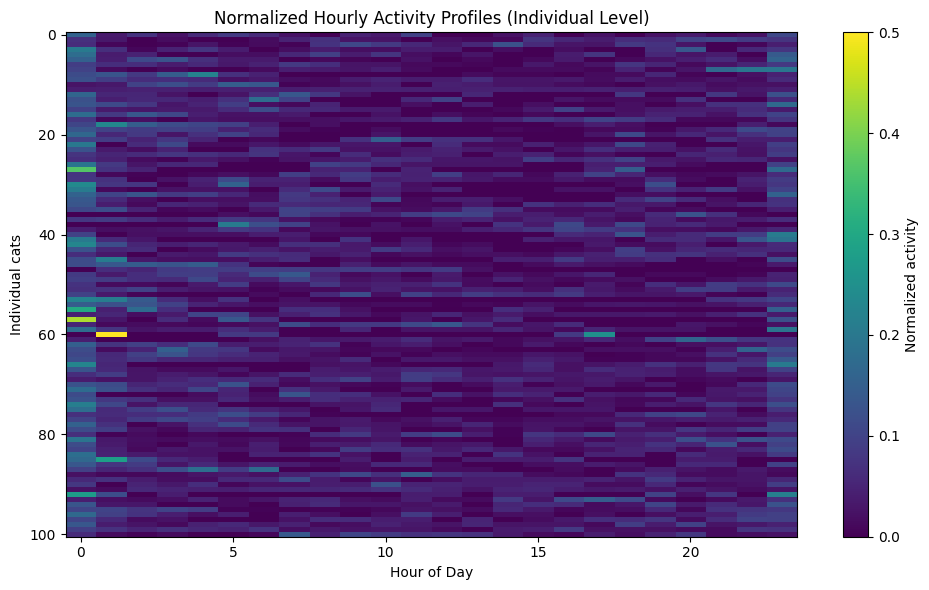

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
avg_profile = hourly_matrix.mean(axis=0)
plt.figure(figsize=(10, 6))
plt.imshow(hourly_matrix, aspect="auto", cmap="viridis")
plt.colorbar(label="Normalized activity")
plt.xlabel("Hour of Day")
plt.ylabel("Individual cats")
plt.title("Normalized Hourly Activity Profiles (Individual Level)")
plt.tight_layout()
plt.show()

**4.Hierarchical Clustering Analysis**

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

# Individual cats level hourly activity profiles:
#row:cat,column:hour
X = hourly_matrix.values
cat_ids = hourly_matrix.index.astype(str).tolist()


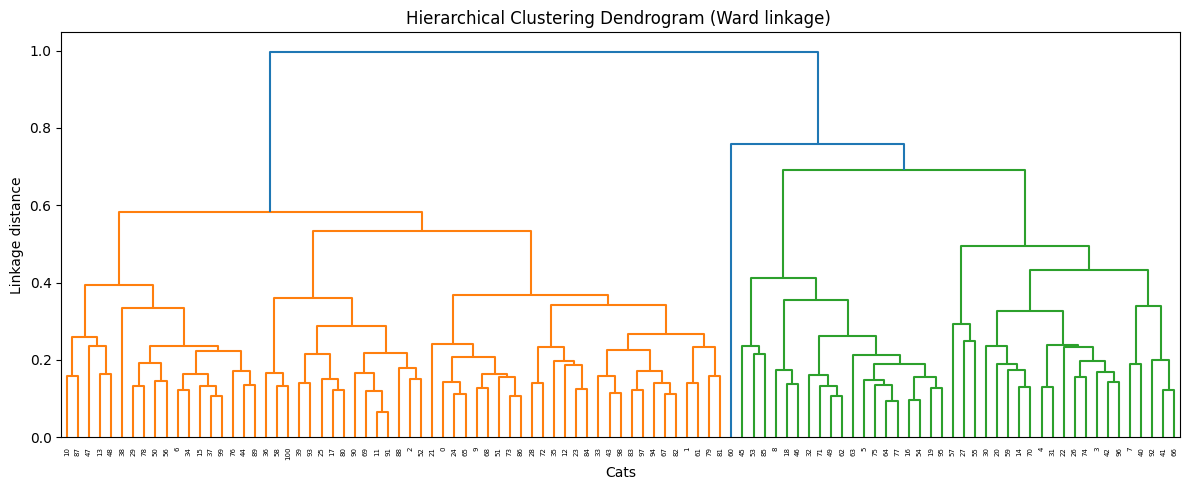

In [11]:
Z = linkage(X, method="ward")
plt.figure(figsize= (12, 5))
dendrogram(Z, )
plt.title("Hierarchical Clustering Dendrogram (Ward linkage) ")
plt.xlabel("Cats")
plt.ylabel("Linkage distance")
plt.tight_layout()
plt.show()

In [12]:
n_clusters = 3
df = hourly_matrix.copy()
df['cluster_labels'] = fcluster(Z, n_clusters, criterion='maxclust').astype(str)
df['cluster_labels'].value_counts()

,count
cluster_labels,
1,60
2,40
3,1


In [13]:
n_clusters = 4
df = hourly_matrix.copy()
df['cluster_labels'] = fcluster(Z, n_clusters, criterion='maxclust').astype(str)
df['cluster_labels'].value_counts()

,count
cluster_labels,
1,60
3,21
2,19
4,1


In [14]:
n_clusters = 2
df = hourly_matrix.copy()
df['cluster_labels'] = fcluster(Z, n_clusters, criterion='maxclust').astype(str)
df['cluster_labels'].value_counts()

,count
cluster_labels,
1,60
2,41
